In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json

In [3]:
DATA_ROOT = "/root/yb-soc-two-body-loss/data/fig4c0920"

In [4]:
def query_condition(name):
    return True
    if "trend" not in name:
        return False
    timestamp = name[-8:]
    if not str.isdigit(timestamp):
        return False
    return "0904" in timestamp

for name in os.listdir(DATA_ROOT):
    if query_condition(name):
        print(name)

temp_nh_13_6_09200418
temp_nh_13_6_09200644
temp_nh_13_6_09201156
sim0_09201702_nh_13_5_09201702
sim0_09201716_nh_13_5_09201716
sim0_09201730_nh_13_5_09201730


In [5]:
DATA_SUBDIR_LIST = [
    "temp_nh_13_6_09200644"
]
DATA_SUBDIR_FULL = [
    os.path.join(DATA_ROOT, name) for name in DATA_SUBDIR_LIST
]

In [6]:
def load_params(data_dir):
    data_path = os.path.join(data_dir, "data/parameters.json")
    with open(data_path, 'r') as f:
        params = json.load(f)
    return params

def load_nparray(data_dir, file_name):
    data_path = os.path.join(data_dir, "data", file_name)
    with open(data_path, 'rb') as f:
        nparr = np.load(f)
    return nparr

def load_times(data_dir):
    return load_nparray(data_dir, "t.npy")

def load_full_momentum_nums(data_dir):
    up_nums = load_nparray(data_dir, "full_up_nums_momentum.npy")
    down_nums = load_nparray(data_dir, "full_down_nums_momentum.npy")
    return up_nums, down_nums

In [7]:
err = 0
params = []
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    params.append(load_params(data_dir))

In [8]:
def merge_params(params_list):
    if not params_list:
        return {}, []

    merged_keys = set()

    def _recursive_merge(current_params_list, path_prefix=""):
        if not current_params_list:
            return {}

        all_keys = set().union(*(d.keys() for d in current_params_list))
        merged_dict = {}

        for key in all_keys:
            values = [d.get(key) for d in current_params_list if key in d]
            
            unique_values = []
            for v in values:
                if v not in unique_values:
                    unique_values.append(v)
            
            full_key_path = f"{path_prefix}{key}"

            if len(unique_values) == 1:
                merged_dict[key] = unique_values[0]
            else:
                if all(isinstance(v, dict) for v in unique_values):
                    merged_dict[key] = _recursive_merge(unique_values, path_prefix=f"{full_key_path}.")
                else:
                    merged_keys.add(full_key_path)
                    merged_dict[key] = unique_values
        
        return merged_dict

    final_merged_dict = _recursive_merge(params_list)

    return final_merged_dict, sorted(list(merged_keys))

In [9]:
merged_params, merged = merge_params(params)
print(merged)
# pointer = merged_params
# for key in merged[0].split('.'):
#     pointer = pointer[key]
# print(f"{key}: {pointer}")
print(json.dumps(merged_params, indent=4))

[]
{
    "k0": 0.5,
    "pa": {
        "gamma": 0.38,
        "T2": 1.25
    },
    "n_particles": 6,
    "L": 12.566370614359172,
    "soc": {
        "k_r": 1.0,
        "delta": 4.0,
        "omega_R": 3.5
    },
    "hbar": 1.0,
    "m_Yb": 1.0,
    "simulation_settings": {
        "t0": 0,
        "t1": 4.0,
        "mode": "non-Hermitian",
        "zerotemp": false,
        "temperature": 0.7388907771653194,
        "n_savesteps": 101,
        "step_size": 0.354295837023915,
        "n_trajectories": 1024,
        "batch_size": 64,
        "jumps_per_step": 4,
        "num_batches": 16,
        "total_n_steps": 400,
        "delta_t": 0.08857395925597875,
        "seed": 0
    },
    "n_momentum_points": 13
}


In [10]:
err = 0
for idx, data_dir in enumerate(DATA_SUBDIR_FULL):
    ts = load_times(data_dir)
    if idx == 0:
        ts_ref = ts
    else:
        err += np.mean(np.abs(ts - ts_ref))
print('error:', err)

error: 0


In [11]:
# System definition
t_r = 0.1129 # ms
E_r = 9.3428e-31 # J
T_r = 6.7669e-2 # μK

In [12]:
ts = ts_ref
ts_ms = ts_ref * t_r
print(f"{len(ts)=}")
print(ts_ms)

len(ts)=101
[0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52 2.56 2.6  2.64 2.68 2.72 2.76
 2.8  2.84 2.88 2.92 2.96 3.   3.04 3.08 3.12 3.16 3.2  3.24 3.28 3.32
 3.36 3.4  3.44 3.48 3.52 3.56 3.6  3.64 3.68 3.72 3.76 3.8  3.84 3.88
 3.92 3.96 4.  ]


In [18]:
t_idx = 50
print(f"{ts_ms[t_idx]} ms")

2.0 ms


In [19]:
gammas = merged_params['pa']['gamma']

In [20]:
gammas

0.38

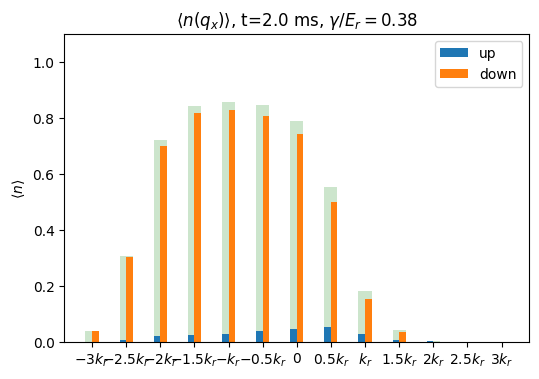

In [21]:
from quant_mech.plot_utils import (
    plot_numbers,
    generate_k_labels,
    plot_fractions, plot_fractions2
)



for data_dir in DATA_SUBDIR_FULL:
    # (batch, time, k)
    params = load_params(data_dir)
    k_tick_labels = generate_k_labels(params["n_momentum_points"], params["k0"])
    nums_up, nums_down = load_full_momentum_nums(data_dir)
    
    assert nums_up.shape[0] == nums_down.shape[0]
    n_batch = nums_up.shape[0]
    
    # (batch, k)
    nums_up = nums_up[:, t_idx, :]
    nums_down = nums_down[:, t_idx, :]
    
    
    nums_up_avg = np.mean(nums_up, axis=0)
    nums_up_error = np.std(nums_up, axis=0) / np.sqrt(n_batch)
    nums_down_avg = np.mean(nums_down, axis=0)
    nums_down_error = np.std(nums_down, axis=0) / np.sqrt(n_batch)
    
    gamma = params["pa"]["gamma"]
    
    plot_numbers(
        nums_up_avg,
        nums_down_avg,
        tick_labels=k_tick_labels, 
        ylim=(0, 1.1),
        title=f"$\\langle n(q_x) \\rangle$, t={ts_ms[t_idx]} ms, $\\gamma/E_r=${gamma}",
    )
    

(13,)


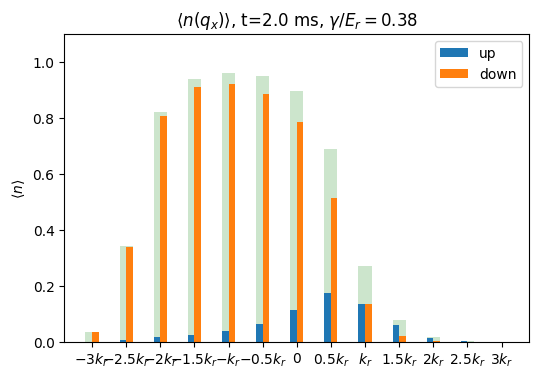

In [25]:
params = load_params(data_dir)
k_tick_labels = generate_k_labels(params["n_momentum_points"], params["k0"])
nums_up, nums_down = load_full_momentum_nums(data_dir)

assert nums_up.shape[0] == nums_down.shape[0]
n_traj = nums_up.shape[0]
n_steps = nums_up.shape[1]

# (batch, k)
nums_up_init = nums_up[:, 0, :]
nums_down_init = nums_down[:, 0, :]


init_nums_up_avg = np.mean(nums_up_init, axis=0)
init_nums_up_error = 3 * np.std(nums_up_init, axis=0) / np.sqrt(n_batch)
init_nums_down_avg = np.mean(nums_down_init, axis=0)
init_nums_down_error = 3 * np.std(nums_down_init, axis=0) / np.sqrt(n_batch)

gamma = params["pa"]["gamma"]

print(init_nums_up_avg.shape)

plot_numbers(
    init_nums_up_avg,
    init_nums_down_avg,
    tick_labels=k_tick_labels, 
    ylim=(0, 1.1),
    title=f"$\\langle n(q_x) \\rangle$, t={ts_ms[t_idx]} ms, $\\gamma/E_r=${gamma}",
)

In [26]:
k_tick_labels_canon = generate_k_labels(params["n_momentum_points"] + 4, params["k0"])
nums_up_initial_canon = np.zeros((params["n_momentum_points"] + 4,))
nums_down_initial_canon = np.zeros((params["n_momentum_points"] + 4,))
nums_up_final_canon = np.zeros((params["n_momentum_points"] + 4,))
nums_down_final_canon = np.zeros((params["n_momentum_points"] + 4,))

In [28]:
nums_up_canon = np.zeros((n_traj, 101, params["n_momentum_points"] + 4))
nums_down_canon = np.zeros((n_traj, 101, params["n_momentum_points"] + 4))

nums_up_canon[:, :, :-4] = nums_up
nums_down_canon[:, :, 4:] = nums_down

In [29]:
nums_up_initial_canon = np.mean(nums_up_canon[:, 0, :], axis=0)
nums_down_initial_canon = np.mean(nums_down_canon[:, 0, :], axis=0)
nums_up_final_canon = np.mean(nums_up_canon[:, -1, :], axis=0)
nums_down_final_canon = np.mean(nums_down_canon[:, -1, :], axis=0)

In [30]:
errors_up_initial_canon = 3 * np.std(nums_up_canon[:, 0, :], axis=0) / np.sqrt(n_traj)
errors_down_initial_canon = 3 * np.std(nums_down_canon[:, 0, :], axis=0) / np.sqrt(n_traj)
errors_up_final_canon = 3 * np.std(nums_up_canon[:, -1, :], axis=0) / np.sqrt(n_traj)
errors_down_final_canon = 3 * np.std(nums_down_canon[:, -1, :], axis=0) / np.sqrt(n_traj)

In [31]:
errors_up_initial_canon

array([5.74288338e-19, 2.84603070e-18, 1.98408998e-17, 3.12250226e-17,
       3.57786717e-17, 4.81385765e-17, 8.32667268e-17, 2.13370988e-16,
       4.42354486e-17, 1.47017815e-16, 2.22803546e-17, 2.50044126e-18,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00])

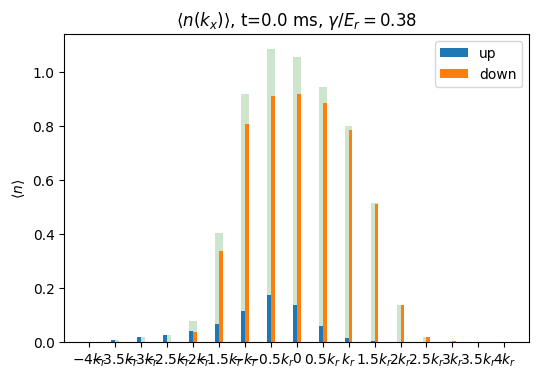

In [32]:
plot_numbers(
    nums_up_initial_canon,
    nums_down_initial_canon,
    tick_labels=k_tick_labels_canon, 
    title=f"$\\langle n(k_x) \\rangle$, t={ts_ms[0]} ms, $\\gamma/E_r=${gamma}",
)

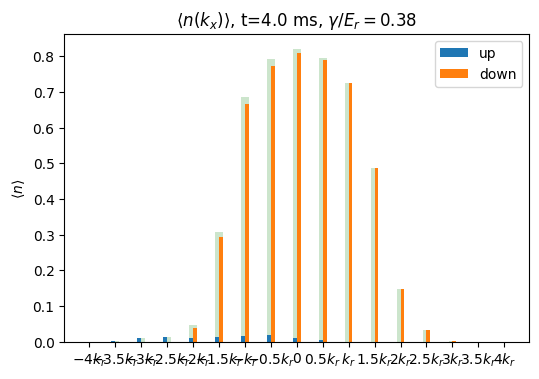

In [33]:
plot_numbers(
    nums_up_final_canon,
    nums_down_final_canon,
    tick_labels=k_tick_labels_canon, 
    title=f"$\\langle n(k_x) \\rangle$, t={ts_ms[-1]} ms, $\\gamma/E_r=${gamma}",
)

In [34]:
def calc_loss_frac(initial, final, eps=1e-6):
    return np.where(np.abs(initial) < eps, np.zeros_like(initial), 1 - final / initial)

In [35]:
nums_up_initial_canon
nums_down_initial_canon
nums_total_initial_canon = nums_up_initial_canon + nums_down_initial_canon
nums_up_final_canon
nums_down_final_canon
nums_total_final_canon = nums_up_final_canon + nums_down_final_canon

In [36]:
up_loss_frac = calc_loss_frac(nums_up_initial_canon, nums_up_final_canon)
down_loss_frac = calc_loss_frac(nums_down_initial_canon, nums_down_final_canon)
total_loss_frac = calc_loss_frac(nums_total_initial_canon, nums_total_final_canon)

/tmp/ipykernel_77801/1072811904.py:2: RuntimeWarning: divide by zero encountered in divide
  return np.where(np.abs(initial) < eps, np.zeros_like(initial), 1 - final / initial)
/tmp/ipykernel_77801/1072811904.py:2: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(initial) < eps, np.zeros_like(initial), 1 - final / initial)


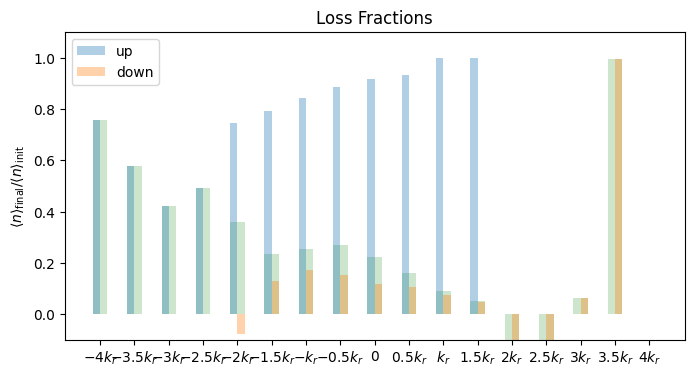

In [37]:
plot_fractions(
    up_loss_frac,
    down_loss_frac,
    total_loss_frac,
    title="Loss Fractions",
    tick_labels=k_tick_labels_canon,  
)


/root/yb-soc-two-body-loss/src/quant_mech/plot_utils.py:125: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


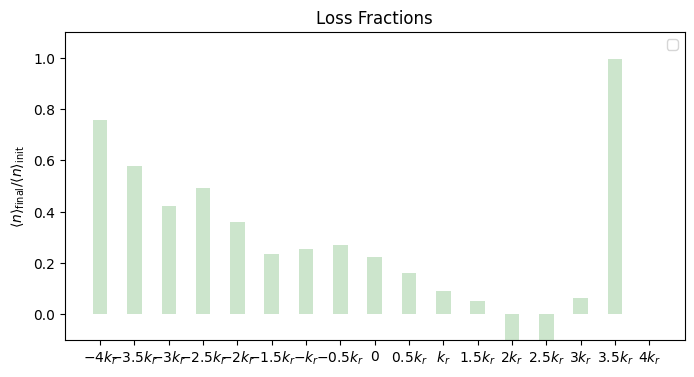

In [38]:
plot_fractions2(
    up_loss_frac,
    down_loss_frac,
    total_loss_frac,
    title="Loss Fractions",
    tick_labels=k_tick_labels_canon,  
)


: 